<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/Predicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics and Text Mining Course → 6 CFU

Project: Predicting Online News Popularity

Author: Safoura Banihashemi

Professor: Dr. Stefano Lodi

Academic Year: 2024-2025

---

Classification algorithm:

1. Logistic Regression
2. Random Forest
3. Gradient Boosted tree

---

Explain

---

Dataset

## requirements

In [1]:
!pip install pyspark
!pip install ucimlrepo

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col as scol

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, UnivariateFeatureSelector
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}\n")

Spark version: 4.0.2



## Data Loading & Exploration

In [33]:
from ucimlrepo import fetch_ucirepo

online_news_popularity = fetch_ucirepo(id=332)
X = online_news_popularity.data.features
y = online_news_popularity.data.targets

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}")

Samples : 39644
Features: 58


In [34]:
print(f"Feature list: {X.columns}")

Feature list: Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_p

In [35]:
# Merge into one pandas frame
df = pd.concat([X, y], axis=1)

# Remove whitespace from column name
df.columns = df.columns.str.strip()
X.columns = X.columns.str.strip()
y.columns = y.columns.str.strip()

In [36]:
# Print some samples
df.head(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [37]:
# Clean dataset (Remove Null & dupplicate rows)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Rows after clean: {len(df)}")

Missing values : 0
Duplicate rows : 0
Rows after clean: 39644


## Binary Classification Label

In [38]:
# Calculate the median of the target variable
THRESHOLD = int(df['shares'].median())
print(f"Median shares: {THRESHOLD}")

df["label"] = (df["shares"] >= THRESHOLD).astype(int)
df.drop(columns=["shares"], inplace=True)

counts = df["label"].value_counts()
total  = len(df)
print(f"\nClass distribution:")
print(f"Popular(1): {counts.get(1,0)} ({counts.get(1,0)/total:.2%})")
print(f"Unpopular(0): {counts.get(0,0)} ({counts.get(0,0)/total:.2%})")

Median shares: 1400

Class distribution:
Popular(1): 21154 (53.36%)
Unpopular(0): 18490 (46.64%)


In [39]:
df.sample(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,label
17566,10.0,452.0,0.533937,1.0,0.719231,11.0,4.0,7.0,0.0,4.730088,...,0.050000,1.0,-0.334375,-0.6,-0.125,0.450000,0.175000,0.050000,0.175000,0
30616,11.0,1368.0,0.424130,1.0,0.736280,10.0,0.0,1.0,0.0,4.345029,...,0.033333,1.0,-0.303571,-0.7,-0.050,0.333333,0.166667,0.166667,0.166667,1
3044,8.0,150.0,0.657718,1.0,0.813953,3.0,0.0,0.0,1.0,4.573333,...,0.136364,0.6,-0.358333,-0.6,-0.150,0.000000,0.000000,0.500000,0.000000,1
17614,11.0,173.0,0.630058,1.0,0.672131,14.0,3.0,8.0,1.0,4.653179,...,0.100000,1.0,-0.850000,-1.0,-0.700,0.900000,0.600000,0.400000,0.600000,0
38868,11.0,338.0,0.633229,1.0,0.764423,13.0,2.0,1.0,1.0,4.902367,...,0.100000,0.5,-0.633333,-1.0,-0.400,0.000000,0.000000,0.500000,0.000000,0


## Exploratory Data Analysis

In [40]:
PALETTE = ["#C781A8", "#835496"]
COLORS  = ["#2E86AB", "#E84855", "#F6AE2D", "#2DC653"]

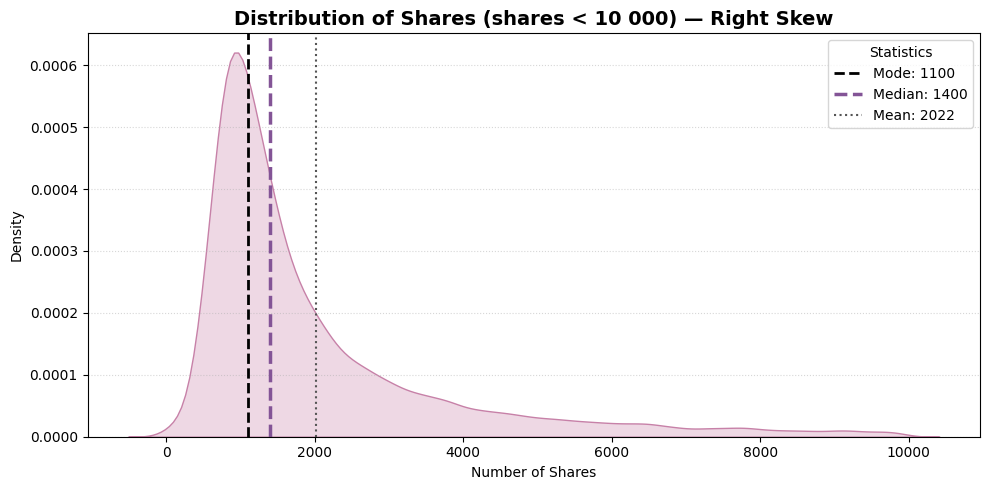

In [41]:
# Shares distribution

# Filter out outliers
filtered_y = y[y['shares'] < 10_000]['shares'].copy()

# Compute mean, median and mode
mean_val   = filtered_y.mean()
median_val = filtered_y.median()
mode_val   = filtered_y.mode()[0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(filtered_y, color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)
ax.axvline(mode_val,   color='black',   linestyle='--', linewidth=2,   label=f'Mode: {mode_val:.0f}')
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
ax.axvline(mean_val,   color='#555555', linestyle=':',  linewidth=1.5, label=f'Mean: {mean_val:.0f}')
ax.set_title("Distribution of Shares (shares < 10 000) — Right Skew", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Shares"); ax.set_ylabel("Density")
ax.set_facecolor('white'); ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(title="Statistics")
plt.tight_layout()
plt.show()

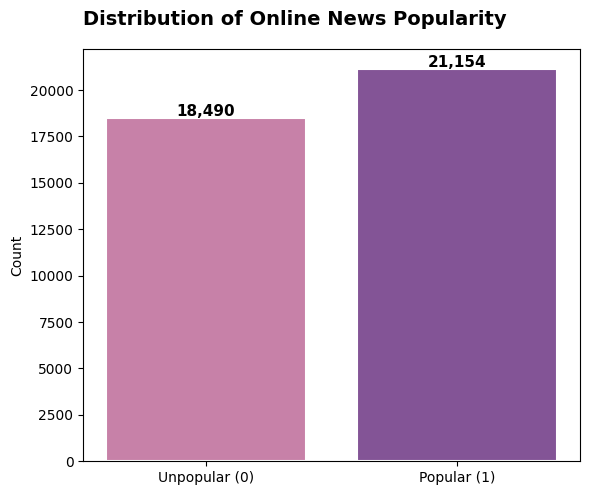

In [43]:
# Class Balance

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Distribution of Online News Popularity", fontsize=14, fontweight="bold")
counts_plot = df["label"].value_counts().sort_index()
bars = ax.bar(["Unpopular (0)", "Popular (1)"], counts_plot.values,
              color=PALETTE, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, counts_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f"{v:,}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [58]:
# Outlier Analysis

y_max = y['shares'].max()
print(f"Max shares: {y_max}")

shares_temp = y['shares'].copy()

Q1 = shares_temp.quantile(0.25)
Q3 = shares_temp.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

extreme = (shares_temp > upper_bound).sum()
print(f"\n75% of articles have fewer shares than {int(Q3)}")
print(f"IQR-based outlier threshold: {int(upper_bound)}")
print(f"Outliers above threshold: {extreme} ({extreme/len(shares_temp):.2%})")

Max shares: 843300

75% of articles have fewer shares than 2800
IQR-based outlier threshold: 5581
Outliers above threshold: 4541 (11.45%)


The IQR method with 1.5 multiplier was designed for normally distributed (bell-shaped) data. It flags roughly 0.7% of data as outliers but since this dataset is extremely right-skewed is normal that consider 11.45% of data as outlier to decreasing this can use 3 × IQR instead of 1.5.

Outliers above threshold: 2765 (6.97%)


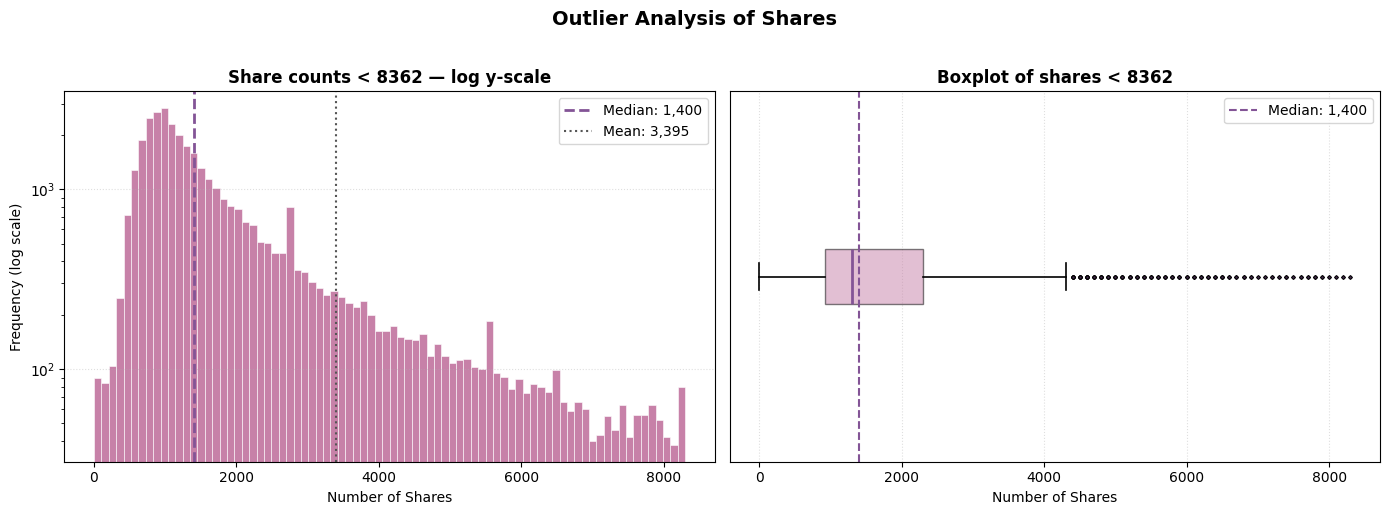

In [65]:
# plot
upper_bound = int(Q3 + 3 * IQR)
extreme = (shares_temp > upper_bound).sum()
print(f"Outliers above threshold: {extreme} ({extreme/len(shares_temp):.2%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with log y-scale
data_hist = shares_temp[shares_temp < upper_bound]
axes[0].hist(data_hist, bins=80, color="#C781A8", edgecolor='white', linewidth=0.4)
axes[0].set_yscale('log')                          # log y-axis reveals the tail shape
axes[0].axvline(shares_temp.median(), color='#835496',
                linestyle='--', linewidth=2, label=f'Median: {shares_temp.median():,.0f}')
axes[0].axvline(shares_temp.mean(), color='#555555',
                linestyle=':', linewidth=1.5, label=f'Mean: {shares_temp.mean():,.0f}')
axes[0].set_title(f"Share counts < {upper_bound} — log y-scale", fontweight='bold')
axes[0].set_xlabel("Number of Shares")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].legend()
axes[0].grid(axis='y', linestyle=':', alpha=0.4)

# Right: horizontal boxplot
data_box = shares_temp[shares_temp < upper_bound]
axes[1].boxplot(data_box, vert=False,              # horizontal is easier to read
                patch_artist=True,
                boxprops=dict(facecolor="#C781A8", alpha=0.5),
                medianprops=dict(color='#835496', linewidth=2),
                flierprops=dict(marker='.', markerfacecolor='#835496',
                                alpha=0.2, markersize=3),  # smaller outlier dots
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
axes[1].set_title(f"Boxplot of shares < {upper_bound}", fontweight='bold')
axes[1].set_xlabel("Number of Shares")
axes[1].set_yticks([])                             # removes the "1" tick
axes[1].axvline(shares_temp.median(), color='#835496',
                linestyle='--', linewidth=1.5, label=f'Median: {shares_temp.median():,.0f}')
axes[1].legend()
axes[1].grid(axis='x', linestyle=':', alpha=0.4)

plt.suptitle("Outlier Analysis of Shares", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pearson correlation heatmap (top 20 features)

### Pearson Correlation (r)

Pearson Correlation is a way to calculate the pairwise correlation between a single target (label) and a set of other variables.

Mathematically, it measures the linear relationship between two variables, $X$ (feature) and $Y$ (label), using this formula:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$$

- Numerator (Covariance): It checks if $X$ and $Y$ move together. If $X$ is above its mean when $Y$ is also above its mean, the correlation goes up.

- Denominator (Normalization): It divides by the product of the standard deviations. This "squashes" the result into a range between -1.0 and +1.0.

- The results:

  - +1.0: Perfect positive linear relationship.

  - 1.0: Perfect negative linear relationship.

  - 0: No linear relationship at all.

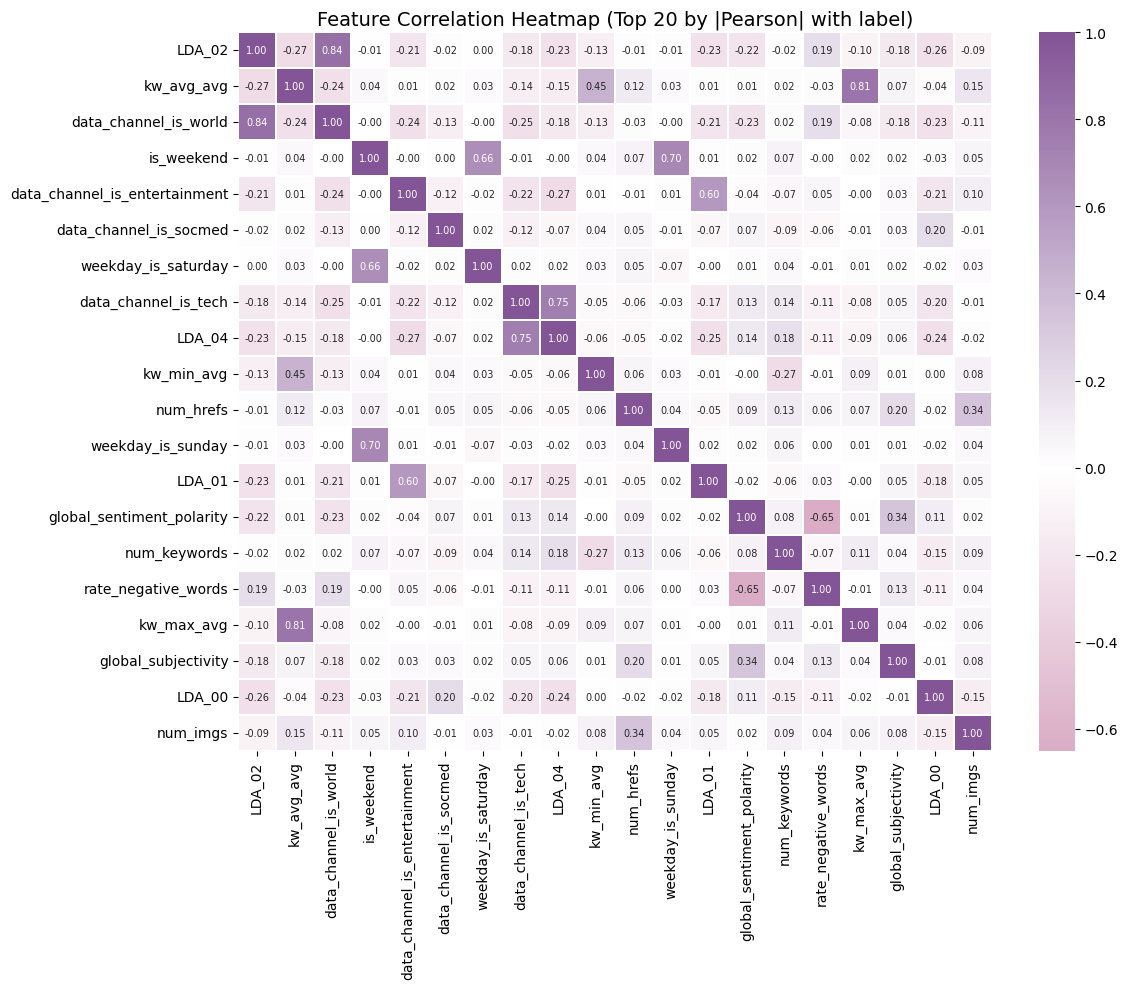

In [68]:
feature_list = [c for c in df.columns if c != "label"]
label_corr   = df[feature_list].corrwith(df["label"]).abs().nlargest(20)
top20_features = label_corr.index.tolist()

colors_cmap = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors_cmap)

plt.figure(figsize=(12, 10))
sub_corr = df[top20_features].corr()
sns.heatmap(sub_corr, cmap=cmap, center=0, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap (Top 20 by |Pearson| with label)", fontsize=14)
plt.tight_layout(); plt.show()

### Relative mean difference between popular vs unpopular articles

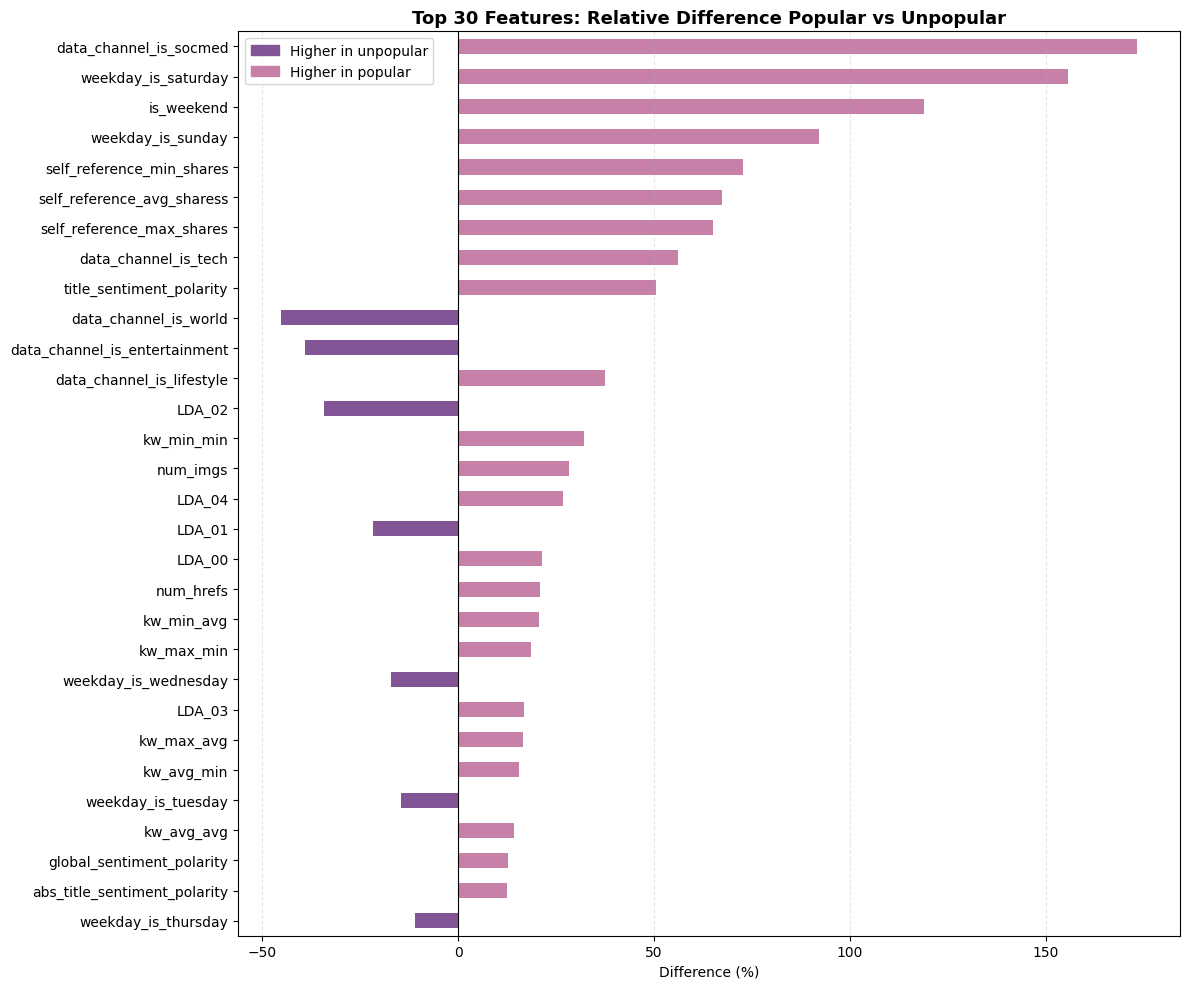

In [69]:
unpopular_mean = df[df['label'] == 0].mean(numeric_only=True)
popular_mean   = df[df['label'] == 1].mean(numeric_only=True)

class_diff = pd.DataFrame({'Mean_Unpopular': unpopular_mean,
                            'Mean_Popular':   popular_mean})
class_diff['Diff (%)'] = (
    (class_diff['Mean_Popular'] - class_diff['Mean_Unpopular'])
    / class_diff['Mean_Unpopular'].replace(0, np.nan)
) * 100
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()
class_diff = class_diff.drop('label', errors='ignore')

top30_diff  = class_diff.sort_values('Abs_Diff', ascending=False).head(30)
colors_diff = np.where(top30_diff['Diff (%)'] > 0, PALETTE[0], PALETTE[1])

plt.figure(figsize=(12, 10))
top30_diff['Diff (%)'].plot(kind='barh', color=colors_diff)
plt.title('Top 30 Features: Relative Difference Popular vs Unpopular',
          fontsize=13, fontweight='bold')
plt.xlabel('Difference (%)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()
purple_patch = mpatches.Patch(color='#835496', label='Higher in unpopular')
pink_patch   = mpatches.Patch(color='#C781A8', label='Higher in popular')
plt.legend(handles=[purple_patch, pink_patch])
plt.tight_layout(); plt.show()

## Feature Engineering

### Why this matters
Raw features fed into the original model had two problems:
1. **Skewed distributions**: features like `n_tokens_content`, `self_reference_avg_shares`, and keyword
   counts span several orders of magnitude. Log-transforming them compresses the tail, stabilises
   variance, and is especially important for Logistic Regression which assumes roughly Gaussian inputs.
2. **Missing interaction signals**: the ratio of links to content length, or the combined keyword
   strength, are meaningful signals that neither feature alone captures. We add 6 engineered features.

In [70]:
# Push to Spark
sdf = spark.createDataFrame(df)
sdf.printSchema()
print(f"Total rows in Spark df: {sdf.count()}")

root
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: double (nullable = true)
 |-- kw_max_min: double (nullable = true)
 |-- kw_avg_min: double (nullable = true)
 |-- kw_min_max: double (nullab

In [75]:
# Pearson pre-filter (|r| > 0.01)

corr_with_label = (
    df.drop(columns=["label"])
    .corrwith(df["label"]).abs()
    .sort_values(ascending=False)
)

feature_cols = [c for c in sdf.columns if c != "label"]
# Remove statistically insignificant correlations
pre_filtered = corr_with_label[corr_with_label > 0.01].index.tolist()
print(f"Pre-filter (|corr| > 0.01): {len(feature_cols)} → {len(pre_filtered)} features")

Pre-filter (|corr| > 0.01): 58 → 48 features


Sweep sample — train: 11,228   val: 2,693

ANOVA feature selection sweep (UnivariateFeatureSelector + LR AUC):

     k       AUC   Δ vs prev   Selected?
  ----  --------  ----------  ----------
    10  0.6823      baseline  YES
    20  0.6874       +0.0050  YES
    30  0.6897       +0.0024  YES
    40  0.6996       +0.0099  YES
    48  0.7000       +0.0004  YES

Best k = 48 (AUC = 0.7000)


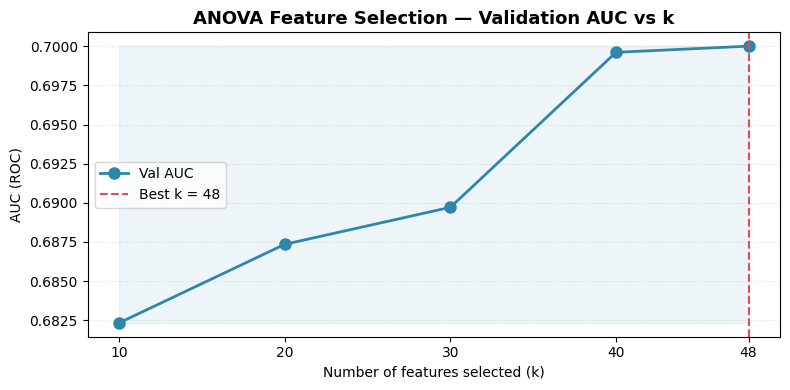

In [79]:
#ANOVA F-test sweep (k = 20, 30, 40, 50)

# Assembler & Scaler
assembler = VectorAssembler(
    inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip"
)
scaler = StandardScaler(
    inputCol="raw_features", outputCol="scaled_features",
    withMean=True, withStd=True
)

# ── Sample for sweep ───────────────────────────────────────────────────────────
# 35% sample is enough to get stable AUC estimates while keeping sweep fast.
# Split computed ONCE so every k candidate sees the exact same train/val data —
# without this, AUC differences between k values could reflect split randomness
# rather than feature quality.
sdf_sample       = sdf.sample(fraction=0.35, seed=42)
train_s, val_s   = sdf_sample.randomSplit([0.8, 0.2], seed=42)
print(f"Sweep sample — train: {train_s.count():,}   val: {val_s.count():,}")

# ── ANOVA sweep ────────────────────────────────────────────────────────────────
# UnivariateFeatureSelector with featureType=continuous + labelType=categorical
# applies an ANOVA F-test — the statistically correct test for continuous inputs
# predicting a binary label. Pearson correlation would miss nonlinear effects;
# chi-squared would require discrete inputs. ANOVA is the right choice here.
#
# We use LR as the sweep model because it is fast and its AUC is a reliable
# proxy for downstream RF/GBT performance at feature selection stage.
# regParam=0.01 is kept consistent with the downstream LR grid.
#
# The +0.0001 improvement guard prevents choosing a larger k when the AUC
# gain is within sampling noise — without it, ties always favour more features.

k_candidates     = [10, 20, 30, 40, 48]   # added k=10 to probe aggressive selection
auc_scores       = {}
best_k, best_auc = 0, 0.0

print("\nANOVA feature selection sweep (UnivariateFeatureSelector + LR AUC):\n")
print(f"  {'k':>4}  {'AUC':>8}  {'Δ vs prev':>10}  {'Selected?':>10}")
print(f"  {'-'*4}  {'-'*8}  {'-'*10}  {'-'*10}")

prev_auc = None
for k in k_candidates:
    # Define selector fresh each iteration — reusing the same object
    # across loop iterations causes Spark to share state incorrectly
    selector_sweep = UnivariateFeatureSelector(
        featuresCol="scaled_features",
        outputCol="sel_features",
        labelCol="label",
        selectionMode="numTopFeatures"
    ).setFeatureType("continuous") \
     .setLabelType("categorical")  \
     .setSelectionThreshold(k)

    lr_tmp = LogisticRegression(
        featuresCol="sel_features", labelCol="label",
        maxIter=20, regParam=0.01
    )

    pipe_tmp  = Pipeline(stages=[assembler, scaler, selector_sweep, lr_tmp])
    model_tmp = pipe_tmp.fit(train_s)
    preds_tmp = model_tmp.transform(val_s)

    auc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(preds_tmp)

    auc_scores[k] = auc

    delta     = f"{auc - prev_auc:+.4f}" if prev_auc is not None else "baseline"
    is_best   = auc > (best_auc + 0.0001)
    selected  = "YES" if is_best else ""
    print(f"  {k:>4}  {auc:.4f}    {delta:>10}  {selected}")

    if is_best:
        best_auc, best_k = auc, k
    prev_auc = auc

print(f"\nBest k = {best_k} (AUC = {best_auc:.4f})")

# Plot AUC vs k
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(list(auc_scores.keys()), list(auc_scores.values()),
        marker="o", color="#2E86AB", linewidth=2, markersize=8, label="Val AUC")

# Shade the region between min and max AUC to show how flat the curve is
auc_vals = list(auc_scores.values())
ax.fill_between(list(auc_scores.keys()),
                min(auc_vals), max(auc_vals),
                alpha=0.08, color="#2E86AB")

# Mark the best k with a vertical line and annotation
ax.axvline(best_k, color="#E84855", linestyle="--", linewidth=1.5,
           label=f"Best k = {best_k}")

ax.set_title("ANOVA Feature Selection — Validation AUC vs k", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of features selected (k)")
ax.set_ylabel("AUC (ROC)")
ax.set_xticks(k_candidates)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Final selector for all training pipelines
selector_final = UnivariateFeatureSelector(
    featuresCol="scaled_features",
    outputCol="features",
    labelCol="label",
    selectionMode="numTopFeatures"
).setFeatureType("continuous") \
 .setLabelType("categorical")  \
 .setSelectionThreshold(best_k)

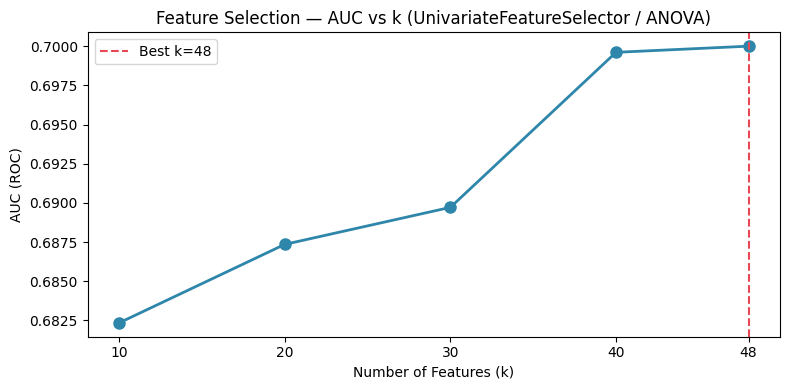

In [77]:
# Plot AUC vs k
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(auc_scores.keys()), list(auc_scores.values()),
        marker="o", color="#2E86AB", linewidth=2, markersize=8)
ax.axvline(best_k, color="#E84855", linestyle="--", label=f"Best k={best_k}")
ax.set_title("Feature Selection — AUC vs k (UnivariateFeatureSelector / ANOVA)")
ax.set_xlabel("Number of Features (k)")
ax.set_ylabel("AUC (ROC)")
ax.legend()
ax.set_xticks(k_candidates)
plt.tight_layout()
plt.show()

Sweep sample — train: 11,228   val: 2,693

With pre-filter:    48 features → ANOVA sweep
Without pre-filter: 58 features → ANOVA sweep

───────────────────────────────────────────────────────
  WITH pre-filter (48 input features)
───────────────────────────────────────────────────────
     k       AUC   Δ vs prev   Selected?
  ----  --------  ----------  ----------
    10  0.6823      baseline  ✔ best
    20  0.6874       +0.0050  ✔ best
    30  0.6897       +0.0024  ✔ best
    40  0.6996       +0.0099  ✔ best
    48  0.7000       +0.0004  ✔ best

  ✔ Best k = 48  (AUC = 0.7000)

───────────────────────────────────────────────────────
  WITHOUT pre-filter (58 input features)
───────────────────────────────────────────────────────
     k       AUC   Δ vs prev   Selected?
  ----  --------  ----------  ----------
    10  0.6781      baseline  ✔ best
    20  0.6874       +0.0093  ✔ best
    30  0.6921       +0.0048  ✔ best
    40  0.7017       +0.0096  ✔ best
    48  0.7004       -0.0013  

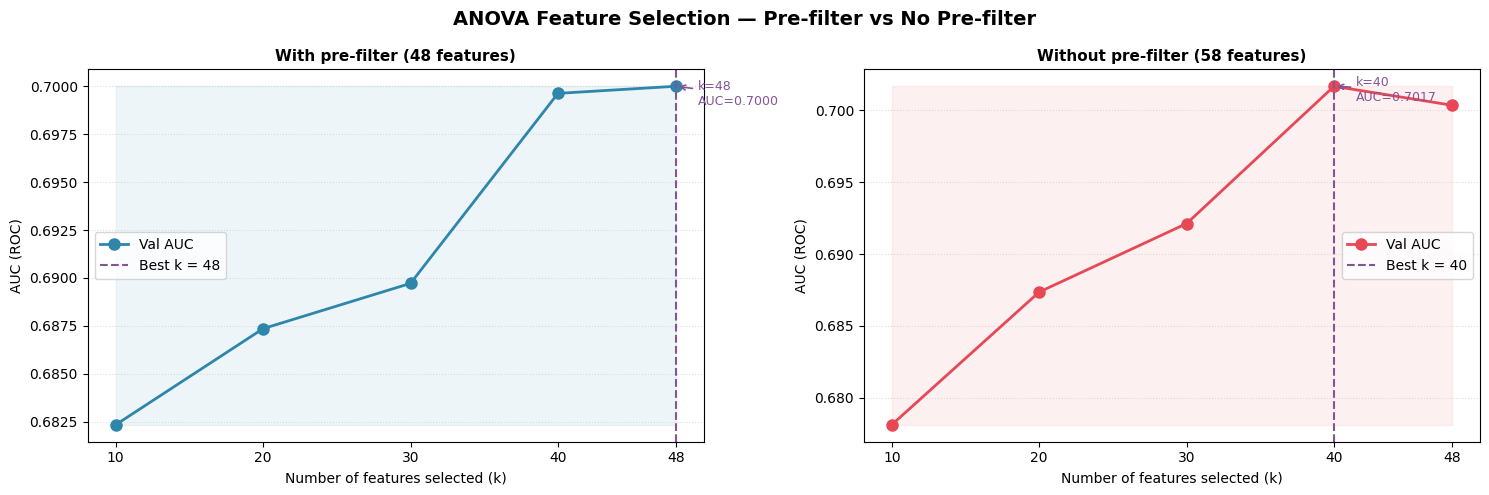


  COMPARISON SUMMARY
  Metric                           Filtered Unfiltered
  ------------------------------ ---------- ----------
  Input features                         48         58
  Best k                                 48         40
  Best AUC                           0.7000     0.7017
  Sweep time (seconds)                 29.7       38.4
  ------------------------------ ---------- ----------
  AUC difference                    -0.0017
  Time saved by filter                 +8.7s

  Conclusion: no pre-filter gives slightly higher AUC —
  consider removing the pre-filter for this dataset.

  → Using unfiltered pipeline (k=40)
  → pre_stages set: Assembler → StandardScaler → ANOVA(k=40)


In [80]:
# ── Assembler & Scaler — TWO versions ─────────────────────────────────────────
# Version A: with pre-filter (only pre_filtered columns)
assembler_filtered = VectorAssembler(
    inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip"
)

# Version B: without pre-filter (all features)
all_feature_cols = [c for c in sdf.columns if c not in ("label", "classWeight", "row_num")]
assembler_all = VectorAssembler(
    inputCols=all_feature_cols, outputCol="raw_features", handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features", outputCol="scaled_features",
    withMean=True, withStd=True
)

# ── Sample for sweep (same sample for both — fair comparison) ──────────────────
sdf_sample     = sdf.sample(fraction=0.35, seed=42)
train_s, val_s = sdf_sample.randomSplit([0.8, 0.2], seed=42)
print(f"Sweep sample — train: {train_s.count():,}   val: {val_s.count():,}")
print(f"\nWith pre-filter:    {len(pre_filtered)} features → ANOVA sweep")
print(f"Without pre-filter: {len(all_feature_cols)} features → ANOVA sweep")

# ── ANOVA sweep function ───────────────────────────────────────────────────────
def run_anova_sweep(assembler, k_candidates, label):
    """
    Runs ANOVA sweep for a given assembler and list of k values.
    Returns dict of {k: auc}.
    """
    auc_scores   = {}
    best_k, best_auc = 0, 0.0
    prev_auc = None

    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  {'k':>4}  {'AUC':>8}  {'Δ vs prev':>10}  {'Selected?':>10}")
    print(f"  {'-'*4}  {'-'*8}  {'-'*10}  {'-'*10}")

    for k in k_candidates:
        selector_sweep = UnivariateFeatureSelector(
            featuresCol="scaled_features",
            outputCol="sel_features",
            labelCol="label",
            selectionMode="numTopFeatures"
        ).setFeatureType("continuous") \
         .setLabelType("categorical")  \
         .setSelectionThreshold(k)

        lr_tmp = LogisticRegression(
            featuresCol="sel_features", labelCol="label",
            maxIter=20, regParam=0.01
        )

        pipe_tmp  = Pipeline(stages=[assembler, scaler, selector_sweep, lr_tmp])
        model_tmp = pipe_tmp.fit(train_s)
        preds_tmp = model_tmp.transform(val_s)

        auc = BinaryClassificationEvaluator(
            labelCol="label", rawPredictionCol="rawPrediction",
            metricName="areaUnderROC"
        ).evaluate(preds_tmp)

        auc_scores[k] = auc

        delta    = f"{auc - prev_auc:+.4f}" if prev_auc is not None else "baseline"
        is_best  = auc > (best_auc + 0.0001)
        selected = "✔ best" if is_best else ""
        print(f"  {k:>4}  {auc:.4f}    {delta:>10}  {selected}")

        if is_best:
            best_auc, best_k = auc, k
        prev_auc = auc

    print(f"\n  ✔ Best k = {best_k}  (AUC = {best_auc:.4f})")
    return auc_scores, best_k, best_auc


# ── Run both sweeps ────────────────────────────────────────────────────────────
import time

k_candidates = [10, 20, 30, 40, 48]

t0 = time.time()
scores_filtered, best_k_filtered, best_auc_filtered = run_anova_sweep(
    assembler_filtered, k_candidates,
    f"WITH pre-filter ({len(pre_filtered)} input features)"
)
time_filtered = time.time() - t0

t0 = time.time()
scores_all, best_k_all, best_auc_all = run_anova_sweep(
    assembler_all, k_candidates,
    f"WITHOUT pre-filter ({len(all_feature_cols)} input features)"
)
time_all = time.time() - t0


# ── Comparison plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("ANOVA Feature Selection — Pre-filter vs No Pre-filter",
             fontsize=14, fontweight='bold')

for ax, scores, best_k, best_auc, label, color in [
    (axes[0], scores_filtered, best_k_filtered, best_auc_filtered,
     f"With pre-filter ({len(pre_filtered)} features)", "#2E86AB"),
    (axes[1], scores_all,      best_k_all,      best_auc_all,
     f"Without pre-filter ({len(all_feature_cols)} features)", "#E84855"),
]:
    auc_vals = list(scores.values())

    ax.plot(list(scores.keys()), auc_vals,
            marker="o", color=color, linewidth=2, markersize=8, label="Val AUC")

    # Shade range to show how flat the curve is
    ax.fill_between(list(scores.keys()),
                    min(auc_vals), max(auc_vals),
                    alpha=0.08, color=color)

    # Best k marker
    ax.axvline(best_k, color="#835496", linestyle="--", linewidth=1.5,
               label=f"Best k = {best_k}")
    ax.annotate(f"k={best_k}\nAUC={best_auc:.4f}",
                xy=(best_k, best_auc),
                xytext=(best_k + 1.5, best_auc - 0.001),
                fontsize=9, color="#835496",
                arrowprops=dict(arrowstyle="->", color="#835496", lw=1.2))

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel("Number of features selected (k)")
    ax.set_ylabel("AUC (ROC)")
    ax.set_xticks(k_candidates)
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


# ── Summary table ──────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  COMPARISON SUMMARY")
print("="*55)
print(f"  {'Metric':<30} {'Filtered':>10} {'Unfiltered':>10}")
print(f"  {'-'*30} {'-'*10} {'-'*10}")
print(f"  {'Input features':<30} {len(pre_filtered):>10} {len(all_feature_cols):>10}")
print(f"  {'Best k':<30} {best_k_filtered:>10} {best_k_all:>10}")
print(f"  {'Best AUC':<30} {best_auc_filtered:>10.4f} {best_auc_all:>10.4f}")
print(f"  {'Sweep time (seconds)':<30} {time_filtered:>10.1f} {time_all:>10.1f}")
auc_diff = best_auc_filtered - best_auc_all
time_saved = time_all - time_filtered
print(f"  {'-'*30} {'-'*10} {'-'*10}")
print(f"  {'AUC difference':<30} {auc_diff:>+10.4f}")
print(f"  {'Time saved by filter':<30} {time_saved:>+10.1f}s")
print("="*55)

if abs(auc_diff) < 0.001:
    print("\n  Conclusion: AUC difference < 0.001 — pre-filter has")
    print(f"  negligible accuracy impact but saved {time_saved:.1f}s.")
elif auc_diff > 0:
    print("\n  Conclusion: pre-filter slightly IMPROVES AUC — the")
    print("  dropped features were adding noise.")
else:
    print("\n  Conclusion: no pre-filter gives slightly higher AUC —")
    print("  consider removing the pre-filter for this dataset.")


# ── Use the better result for final pipeline ───────────────────────────────────
if best_auc_filtered >= best_auc_all:
    best_k_final   = best_k_filtered
    best_assembler = assembler_filtered
    print(f"\n  → Using pre-filtered pipeline (k={best_k_final})")
else:
    best_k_final   = best_k_all
    best_assembler = assembler_all
    print(f"\n  → Using unfiltered pipeline (k={best_k_final})")

selector_final = UnivariateFeatureSelector(
    featuresCol="scaled_features",
    outputCol="features",
    labelCol="label",
    selectionMode="numTopFeatures"
).setFeatureType("continuous") \
 .setLabelType("categorical")  \
 .setSelectionThreshold(best_k_final)

pre_stages = [best_assembler, scaler, selector_final]
print(f"  → pre_stages set: Assembler → StandardScaler → ANOVA(k={best_k_final})")

In [81]:
# ── Fit the final selector on the full sample to see which features are chosen ─
pipe_inspect = Pipeline(stages=[best_assembler, scaler, selector_final])
model_inspect = pipe_inspect.fit(train_s)

# Stage 0 = Assembler, Stage 1 = Scaler, Stage 2 = Selector
fitted_selector  = model_inspect.stages[2]
selected_indices = fitted_selector.selectedFeatures  # list of integer indices

# Map indices back to column names
# The assembler's inputCols defines the index→name mapping
input_col_names   = best_assembler.getInputCols()
selected_features = [input_col_names[i] for i in selected_indices]

print(f"Selected {len(selected_features)} features (k={best_k_final}):\n")
print(f"  {'#':<4}  {'Feature Name':<45}  {'Index'}")
print(f"  {'-'*4}  {'-'*45}  {'-'*5}")
for rank, (name, idx) in enumerate(zip(selected_features, selected_indices), 1):
    print(f"  {rank:<4}  {name:<45}  {idx}")

Selected 40 features (k=40):

  #     Feature Name                                   Index
  ----  ---------------------------------------------  -----
  1     num_hrefs                                      5
  2     num_keywords                                   10
  3     data_channel_is_entertainment                  12
  4     data_channel_is_socmed                         14
  5     data_channel_is_tech                           15
  6     data_channel_is_world                          16
  7     kw_min_avg                                     23
  8     kw_max_avg                                     24
  9     kw_avg_avg                                     25
  10    weekday_is_saturday                            34
  11    weekday_is_sunday                              35
  12    is_weekend                                     36
  13    LDA_01                                         38
  14    LDA_02                                         39
  15    LDA_04                       

In [82]:
dropped_features = [f for f in input_col_names if f not in selected_features]

print(f"\nDropped {len(dropped_features)} features by ANOVA:\n")
for name in dropped_features:
    print(f"  ✗  {name}")


Dropped 18 features by ANOVA:

  ✗  n_tokens_content
  ✗  n_non_stop_words
  ✗  num_videos
  ✗  data_channel_is_bus
  ✗  kw_min_max
  ✗  kw_max_max
  ✗  kw_avg_max
  ✗  weekday_is_monday
  ✗  weekday_is_thursday
  ✗  weekday_is_friday
  ✗  global_rate_negative_words
  ✗  rate_positive_words
  ✗  avg_positive_polarity
  ✗  min_positive_polarity
  ✗  avg_negative_polarity
  ✗  min_negative_polarity
  ✗  max_negative_polarity
  ✗  abs_title_subjectivity


## Rolling-Window Time-Series Split

Unlike a standard cross-validation where data is shuffled randomly, this method respects the temporal order.



Total rows (chronologically ordered): 39,644
Column used for ordering: 'n_tokens_content'

Window parameters:
  W (train + eval) : 20,000
  ├── Train        : 14,000  (70% of W)
  └── Eval         : 6,000  (30% of W)
  L (test / step)  : 3,000
  Total window     : 23,000  (W + L)
  Number of folds  : 6

─────────────────────────────────────────────────────────────────────────────────────
  Fold  Train start  Train end  Eval start  Eval end  Test start  Test end   n_train   n_eval   n_test
─────────────────────────────────────────────────────────────────────────────────────
     1            0     13,999      14,000    19,999      20,000    22,999    14,000    6,000    3,000
     2        3,000     16,999      17,000    22,999      23,000    25,999    14,000    6,000    3,000
     3        6,000     19,999      20,000    25,999      26,000    28,999    14,000    6,000    3,000
     4        9,000     22,999      23,000    28,999      29,000    31,999    14,000    6,000    3,000
     5  

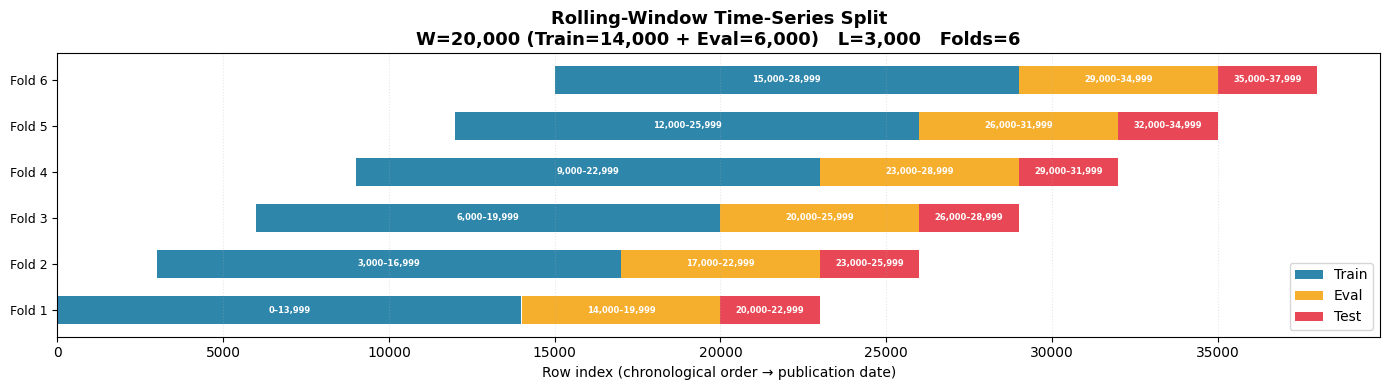


Summary:
  Total articles  : 39,644
  Articles used   : 37,999
  Articles unused : 1,645  (tail too short for another full fold)
  Total test rows : 18,000  (6 folds × 3,000)
  Coverage        : 45.4% of dataset evaluated on test


In [83]:
# ══════════════════════════════════════════════════════════════════════════════
# Rolling-Window Time-Series Split
#
# Design:
#   W = 20,000 rows  →  train (70%) + eval (30%)
#   L =  3,000 rows  →  test (step size = how far window slides each fold)
#
#   Each fold:
#   ┌─────────────────────────────┬──────────────┬──────────┐
#   │   TRAIN (14,000)            │  EVAL (6,000)│TEST(3000)│
#   └─────────────────────────────┴──────────────┴──────────┘
#   │◄──────────────── W ─────────────────────►│◄── L ───►│
#
#   Train  → model fitting
#   Eval   → hyperparameter tuning (CrossValidator) — never touches test
#   Test   → final metric reporting — never seen during any fitting step
#
# Why these numbers:
#   W=20,000 gives enough training history (~1 year of articles)
#   L=3,000  gives statistically stable test metrics (~3k rows per fold)
#   TRAIN_FRAC=0.70 leaves 30% for eval which is enough for 3-fold CV
# ══════════════════════════════════════════════════════════════════════════════

from pyspark.sql.functions import row_number, col as scol
from pyspark.sql.window import Window

# ── Step 1: Assign row numbers in chronological order ─────────────────────────
# coalesce(1) forces a single partition so row_number() produces a perfect
# 0,1,2,...,N sequence without gaps.
# We order by the second column (URL index) which approximates publication date.
sdf_ordered = (
    sdf.coalesce(1)
    .withColumn(
        "row_num",
        row_number().over(Window.orderBy(scol(sdf.columns[1]).desc())) - 1
    )
)

# Cache because we will filter this dataframe many times in the fold loop
sdf_ordered.cache()
total_rows = sdf_ordered.count()

print(f"Total rows (chronologically ordered): {total_rows:,}")
print(f"Column used for ordering: '{sdf.columns[1]}'")

# ── Step 2: Window parameters ──────────────────────────────────────────────────
W          = 20_000   # total window size (train + eval)
L          =  3_000   # step size = test set size per fold
TRAIN_FRAC =  0.70    # fraction of W used for training (rest = eval)

TRAIN_SIZE = int(W * TRAIN_FRAC)   # 14,000
EVAL_SIZE  = W - TRAIN_SIZE        # 6,000
total_window = W + L               # 23,000

# How many complete windows fit in the dataset
num_windows = (total_rows - total_window) // L + 1

print(f"\nWindow parameters:")
print(f"  W (train + eval) : {W:,}")
print(f"  ├── Train        : {TRAIN_SIZE:,}  ({TRAIN_FRAC:.0%} of W)")
print(f"  └── Eval         : {EVAL_SIZE:,}  ({1-TRAIN_FRAC:.0%} of W)")
print(f"  L (test / step)  : {L:,}")
print(f"  Total window     : {total_window:,}  (W + L)")
print(f"  Number of folds  : {num_windows}")

# ── Step 3: Build fold splits ──────────────────────────────────────────────────
splits = []

print(f"\n{'─'*85}")
print(f"  {'Fold':>4}  {'Train start':>11}  {'Train end':>9}  "
      f"{'Eval start':>10}  {'Eval end':>8}  "
      f"{'Test start':>10}  {'Test end':>8}  "
      f"{'n_train':>8}  {'n_eval':>7}  {'n_test':>7}")
print(f"{'─'*85}")

for i in range(num_windows):
    # Starting row index for this fold
    start = i * L

    # ── Train zone: [start, start + TRAIN_SIZE) ───────────────────────────────
    tr_start = start
    tr_end   = start + TRAIN_SIZE - 1

    # ── Eval zone: [start + TRAIN_SIZE, start + W) ────────────────────────────
    ev_start = tr_end + 1
    ev_end   = start + W - 1

    # ── Test zone: [start + W, start + W + L) ────────────────────────────────
    te_start = start + W
    te_end   = min(start + W + L - 1, total_rows - 1)  # boundary guard

    # Filter Spark dataframe for each zone
    train_fold = sdf_ordered.filter(
        (scol("row_num") >= tr_start) & (scol("row_num") <= tr_end)
    )
    eval_fold  = sdf_ordered.filter(
        (scol("row_num") >= ev_start) & (scol("row_num") <= ev_end)
    )
    test_fold  = sdf_ordered.filter(
        (scol("row_num") >= te_start) & (scol("row_num") <= te_end)
    )

    splits.append((train_fold, eval_fold, test_fold))

    # Count rows for verification
    n_train = train_fold.count()
    n_eval  = eval_fold.count()
    n_test  = test_fold.count()

    print(f"  {i+1:>4}  {tr_start:>11,}  {tr_end:>9,}  "
          f"{ev_start:>10,}  {ev_end:>8,}  "
          f"{te_start:>10,}  {te_end:>8,}  "
          f"{n_train:>8,}  {n_eval:>7,}  {n_test:>7,}")

print(f"{'─'*85}")
N_SPLITS = len(splits)
print(f"\nTotal folds created: {N_SPLITS}")

# ── Step 4: Verify no data leakage ────────────────────────────────────────────
# For every fold, test zone must start strictly after train+eval zone ends.
# If any fold fails this check the rolling window logic has a bug.
print("\nLeakage check:")
all_clean = True
for i, (tr, ev, te) in enumerate(splits):
    tr_max = tr.agg(F.max("row_num")).collect()[0][0]
    ev_min = ev.agg(F.min("row_num")).collect()[0][0]
    ev_max = ev.agg(F.max("row_num")).collect()[0][0]
    te_min = te.agg(F.min("row_num")).collect()[0][0]

    train_eval_ok = ev_min == tr_max + 1   # eval starts right after train
    eval_test_ok  = te_min == ev_max + 1   # test starts right after eval

    if not (train_eval_ok and eval_test_ok):
        print(f"  Fold {i+1}: ✗ LEAKAGE DETECTED")
        all_clean = False
    else:
        print(f"  Fold {i+1}: ✔ clean  "
              f"(train ends {tr_max:,} → eval starts {ev_min:,} → "
              f"test starts {te_min:,})")

if all_clean:
    print("\n  ✔ All folds verified — no temporal leakage.")
else:
    print("\n  ✗ Fix the rolling window logic before proceeding!")

# ── Step 5: Class balance check per fold ──────────────────────────────────────
# Skewed folds produce unreliable metrics — especially on the test set.
# Each fold should be close to the global 50/50 balance.
print("\nClass balance per fold (test set):")
print(f"  {'Fold':>4}  {'Class 0':>8}  {'Class 1':>8}  {'% Popular':>10}  {'Balanced?':>10}")
print(f"  {'-'*4}  {'-'*8}  {'-'*8}  {'-'*10}  {'-'*10}")

for i, (_, _, te) in enumerate(splits):
    counts   = te.groupBy("label").count().collect()
    count_0  = next((r["count"] for r in counts if r["label"] == 0), 0)
    count_1  = next((r["count"] for r in counts if r["label"] == 1), 0)
    pct_pop  = count_1 / (count_0 + count_1) * 100
    balanced = "✔" if 40 <= pct_pop <= 60 else "⚠ skewed"
    print(f"  {i+1:>4}  {count_0:>8,}  {count_1:>8,}  {pct_pop:>9.1f}%  {balanced:>10}")

# ── Step 6: Visualise the splits ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(4, N_SPLITS * 0.6)))

for i, (tr, ev, te) in enumerate(splits):
    tr_s = tr.agg(F.min("row_num")).collect()[0][0]
    tr_e = tr.agg(F.max("row_num")).collect()[0][0]
    ev_s = ev.agg(F.min("row_num")).collect()[0][0]
    ev_e = ev.agg(F.max("row_num")).collect()[0][0]
    te_s = te.agg(F.min("row_num")).collect()[0][0]
    te_e = te.agg(F.max("row_num")).collect()[0][0]

    ax.barh(i, tr_e - tr_s, left=tr_s, height=0.6,
            color="#2E86AB", label="Train"  if i == 0 else "")
    ax.barh(i, ev_e - ev_s, left=ev_s, height=0.6,
            color="#F6AE2D", label="Eval"   if i == 0 else "")
    ax.barh(i, te_e - te_s, left=te_s, height=0.6,
            color="#E84855", label="Test"   if i == 0 else "")

    # Annotate each bar with row range
    ax.text(tr_s + (tr_e - tr_s)/2, i, f"{tr_s:,}–{tr_e:,}",
            ha='center', va='center', fontsize=6, color='white', fontweight='bold')
    ax.text(ev_s + (ev_e - ev_s)/2, i, f"{ev_s:,}–{ev_e:,}",
            ha='center', va='center', fontsize=6, color='white', fontweight='bold')
    ax.text(te_s + (te_e - te_s)/2, i, f"{te_s:,}–{te_e:,}",
            ha='center', va='center', fontsize=6, color='white', fontweight='bold')

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)], fontsize=9)
ax.set_xlabel("Row index (chronological order → publication date)")
ax.set_title(
    f"Rolling-Window Time-Series Split\n"
    f"W={W:,} (Train={TRAIN_SIZE:,} + Eval={EVAL_SIZE:,})   "
    f"L={L:,}   Folds={N_SPLITS}",
    fontsize=13, fontweight='bold'
)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Step 7: Summary statistics ─────────────────────────────────────────────────
print(f"\nSummary:")
print(f"  Total articles  : {total_rows:,}")
print(f"  Articles used   : {splits[-1][2].agg(F.max('row_num')).collect()[0][0]:,}")
print(f"  Articles unused : {total_rows - splits[-1][2].agg(F.max('row_num')).collect()[0][0]:,}  "
      f"(tail too short for another full fold)")
print(f"  Total test rows : {N_SPLITS * L:,}  ({N_SPLITS} folds × {L:,})")
print(f"  Coverage        : {N_SPLITS * L / total_rows:.1%} of dataset evaluated on test")

## Model Definitions & Grid Search

In [84]:
# Random Forest
rf = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    seed=42
)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees,             [50, 100])
    .addGrid(rf.maxDepth,             [5, 10])
    .addGrid(rf.minInstancesPerNode,  [1, 5])
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
    .build()
)

# Gradient Boosted Tree
gbt = GBTClassifier(
    featuresCol="features", labelCol="label",
    seed=42, maxIter=50
)
gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth,        [3, 5])
    .addGrid(gbt.stepSize,        [0.05, 0.1])
    .addGrid(gbt.subsamplingRate, [0.7, 1.0])   # stochastic GBT
    .build()
)

# Logistic Regression
lr = LogisticRegression(
    featuresCol="features", labelCol="label",
    maxIter=100
)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0,  0.5])
    .build()
)

model_configs = [
    ("Random Forest",         rf,  rf_grid),
    ("Gradient Boosted Tree", gbt, gbt_grid),
    ("Logistic Regression",   lr,  lr_grid),
]
print("Model configs ready.")
for name, _, grid in model_configs:
    print(f"  {name}: {len(grid)} hyperparameter combinations")

Model configs ready.
  Random Forest: 16 hyperparameter combinations
  Gradient Boosted Tree: 8 hyperparameter combinations
  Logistic Regression: 6 hyperparameter combinations


## Helper Functions

In [85]:
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

def compute_metrics(predictions):
    """Return accuracy / F1 / precision / recall / AUC dict."""
    results = {}
    for key, metric in [
        ("accuracy",  "accuracy"),
        ("f1",        "f1"),
        ("precision", "weightedPrecision"),
        ("recall",    "weightedRecall"),
    ]:
        ev = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric
        )
        results[key] = ev.evaluate(predictions)
    results["auc"] = evaluator_auc.evaluate(predictions)
    return results


def find_best_threshold(model, val_sdf, thresholds=None):
    """
    Sweep decision thresholds on val_sdf and return the one maximising F1.
    Works for any PipelineModel whose last stage exposes a probability column.
    """
    if thresholds is None:
        thresholds = [t / 100 for t in range(25, 76)]   # 0.25 .. 0.75

    preds = model.transform(val_sdf)
    pdf   = preds.select("probability", "label").toPandas()
    probs = [float(row[1]) for row in pdf["probability"]]
    labels = pdf["label"].tolist()

    from sklearn.metrics import f1_score
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        pred_labels = [1 if p >= t else 0 for p in probs]
        f = f1_score(labels, pred_labels, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def apply_threshold(predictions, threshold):
    """Re-derive 'prediction' column using a custom threshold on class-1 probability."""
    get_prob1 = F.udf(lambda v: float(v[1]), "double")
    return (
        predictions
        .withColumn("prob1", get_prob1(F.col("probability")))
        .withColumn("prediction", (F.col("prob1") >= threshold).cast("double"))
    )

In [86]:
def train_and_evaluate(name, estimator, param_grid,
                       train_sdf, eval_sdf, test_sdf,
                       pipeline_stages=None):
    """
    3-way split workflow:
      1. CrossValidator selects best hyperparams on train_sdf (internal 3-fold CV).
      2. Best pipeline is refit on train_sdf + eval_sdf (full W).
      3. Threshold is tuned on eval_sdf (no leakage into test).
      4. Final metrics computed on test_sdf with optimal threshold.
    """
    stages   = pre_stages if pipeline_stages is None else pipeline_stages
    pipeline = Pipeline(stages=stages + [estimator])

    # Step 1: hyperparameter search
    cv = CrossValidator(
        estimator=pipeline, estimatorParamMaps=param_grid,
        evaluator=evaluator_auc, numFolds=3, seed=42, parallelism=2
    )
    print(f"  Fitting {name} …", end=" ", flush=True)
    cv_model = cv.fit(train_sdf)

    # Step 2: refit on full W
    full_W      = train_sdf.union(eval_sdf)
    final_model = pipeline.fit(full_W)
    print("done.")

    # Step 3: threshold tuning on eval set (never on test)
    best_threshold, val_f1 = find_best_threshold(final_model, eval_sdf)
    print(f"    Optimal threshold={best_threshold:.2f}  (val F1={val_f1:.4f})")

    # Step 4: evaluate on test with optimal threshold
    raw_preds   = final_model.transform(test_sdf)
    preds_tuned = apply_threshold(raw_preds, best_threshold)
    metrics     = compute_metrics(preds_tuned)
    metrics["threshold"] = best_threshold

    print(f"  {name}: ACC={metrics['accuracy']:.4f}  "
          f"F1={metrics['f1']:.4f}  AUC={metrics['auc']:.4f}")

    return metrics, final_model

## Training over Rolling-Window Folds

In [87]:
all_results = {name: [] for name, _, _ in model_configs}
all_models = {name: [] for name, _, _ in model_configs}   # store last-fold models for EDA

for fold_idx, (train_fold, eval_fold, test_fold) in enumerate(splits):
    print(f"\n{'─'*55}")
    print(f"Fold {fold_idx + 1}/{N_SPLITS}")
    print(f"{'─'*55}")

    for name, estimator, param_grid in model_configs:
        metrics, model = train_and_evaluate(
            name, estimator, param_grid,
            train_fold, eval_fold, test_fold
        )
        all_results[name].append(metrics)
        all_models[name].append(model)


───────────────────────────────────────────────────────
Fold 1/6
───────────────────────────────────────────────────────
  Fitting Random Forest … done.
    Optimal threshold=0.42  (val F1=0.6961)
  Random Forest: ACC=0.6057  F1=0.5715  AUC=0.6984
  Fitting Gradient Boosted Tree … done.
    Optimal threshold=0.35  (val F1=0.7469)
  Gradient Boosted Tree: ACC=0.6350  F1=0.6180  AUC=0.7111
  Fitting Logistic Regression … done.
    Optimal threshold=0.34  (val F1=0.6907)
  Logistic Regression: ACC=0.6077  F1=0.5813  AUC=0.7003

───────────────────────────────────────────────────────
Fold 2/6
───────────────────────────────────────────────────────
  Fitting Random Forest … done.
    Optimal threshold=0.39  (val F1=0.6974)
  Random Forest: ACC=0.6003  F1=0.5405  AUC=0.6998
  Fitting Gradient Boosted Tree … done.
    Optimal threshold=0.43  (val F1=0.7440)
  Gradient Boosted Tree: ACC=0.6487  F1=0.6419  AUC=0.7073
  Fitting Logistic Regression … done.
    Optimal threshold=0.34  (val F1=0.6

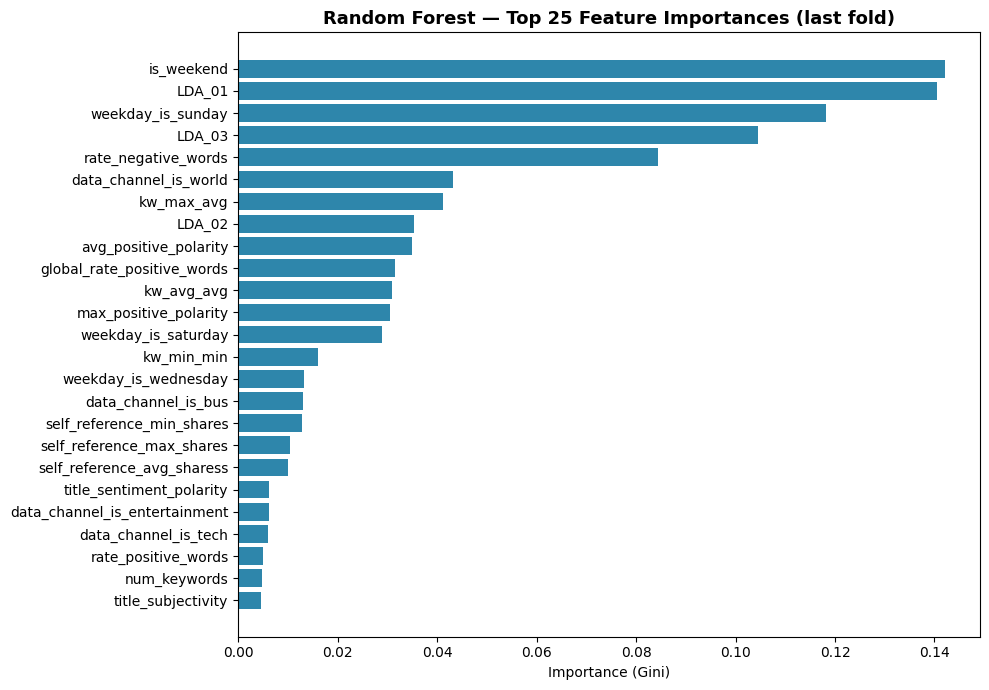


Pearson ranking vs RF importance for top 10 RF features:
  is_weekend                                    RF rank:  1   Pearson rank: 4
  LDA_01                                        RF rank:  2   Pearson rank: 13
  weekday_is_sunday                             RF rank:  3   Pearson rank: 12
  LDA_03                                        RF rank:  4   Pearson rank: 24
  rate_negative_words                           RF rank:  5   Pearson rank: 16
  data_channel_is_world                         RF rank:  6   Pearson rank: 3
  kw_max_avg                                    RF rank:  7   Pearson rank: 17
  LDA_02                                        RF rank:  8   Pearson rank: 1
  avg_positive_polarity                         RF rank:  9   Pearson rank: 41
  global_rate_positive_words                    RF rank: 10   Pearson rank: 22


In [88]:
# Use the last fold's RF model
last_rf_model = all_models["Random Forest"][-1]

# The pipeline stages are: 0=Assembler, 1=Scaler, 2=Selector, 3=RF
rf_stage      = last_rf_model.stages[-1]
sel_stage     = last_rf_model.stages[2]
selected_idx  = sel_stage.selectedFeatures

# Map indices back to column names
# Use the assembler's inputCols — this is always correct regardless
# of whether you used pre_filtered or all_feature_cols
input_col_names = best_assembler.getInputCols()
selected_names  = [input_col_names[i] for i in selected_idx]

importances = rf_stage.featureImportances.toArray()
feat_imp_df = (
    pd.DataFrame({"feature": selected_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp_df["feature"][::-1], feat_imp_df["importance"][::-1],
        color="#2E86AB")
ax.set_title("Random Forest — Top 25 Feature Importances (last fold)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

print("\nPearson ranking vs RF importance for top 10 RF features:")
for _, row in feat_imp_df.head(10).iterrows():
    if row['feature'] in corr_with_label.index:
        pearson_rank = corr_with_label.index.tolist().index(row['feature']) + 1
    else:
        pearson_rank = "N/A"
    rf_rank = feat_imp_df['feature'].tolist().index(row['feature']) + 1
    print(f"  {row['feature']:<45} RF rank: {rf_rank:>2}   Pearson rank: {pearson_rank}")

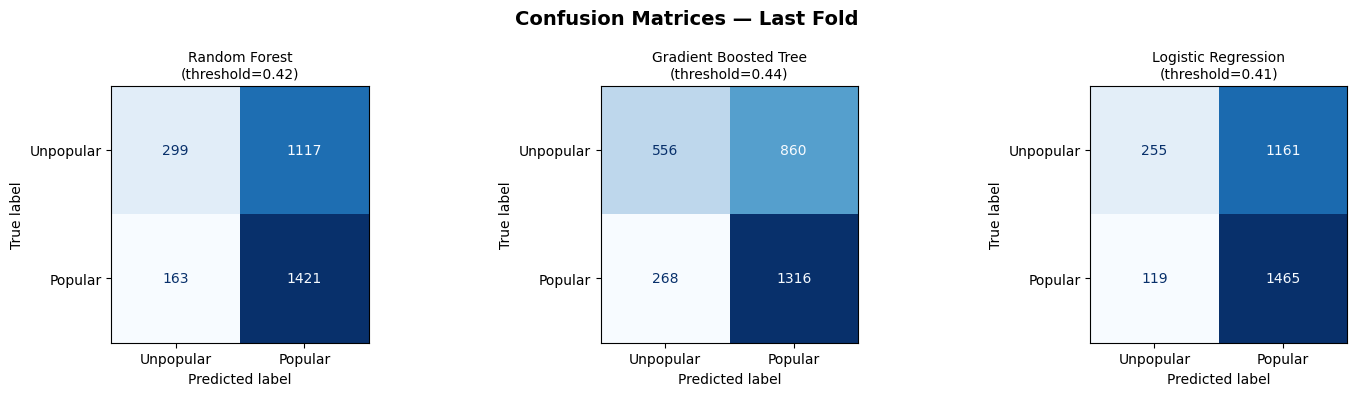

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices — Last Fold", fontsize=14, fontweight='bold')

for ax, (name, _, _) in zip(axes, model_configs):
    last_model = all_models[name][-1]
    last_test  = splits[-1][2]

    raw_preds  = last_model.transform(last_test)
    best_t     = all_results[name][-1]["threshold"]
    tuned      = apply_threshold(raw_preds, best_t)

    pdf = tuned.select("label", "prediction").toPandas()
    cm  = confusion_matrix(pdf["label"], pdf["prediction"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Unpopular", "Popular"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\n(threshold={best_t:.2f})", fontsize=10)

plt.tight_layout(); plt.show()

In [90]:
model_names = list(all_results.keys())
metric_keys = ["accuracy", "f1", "precision", "recall", "auc"]

avg_results = {
    mname: {mk: np.mean([f[mk] for f in all_results[mname]]) for mk in metric_keys}
    for mname in model_names
}

summary_df = pd.DataFrame(avg_results).T[metric_keys]
summary_df.index.name = "Model"
print("\nAverage Metrics across Rolling Folds:")
print(summary_df.round(4).to_string())


Average Metrics across Rolling Folds:
                       accuracy      f1  precision  recall     auc
Model                                                             
Random Forest            0.6013  0.5493     0.6478  0.6013  0.6856
Gradient Boosted Tree    0.6409  0.6290     0.6497  0.6409  0.6998
Logistic Regression      0.6038  0.5582     0.6391  0.6038  0.6831


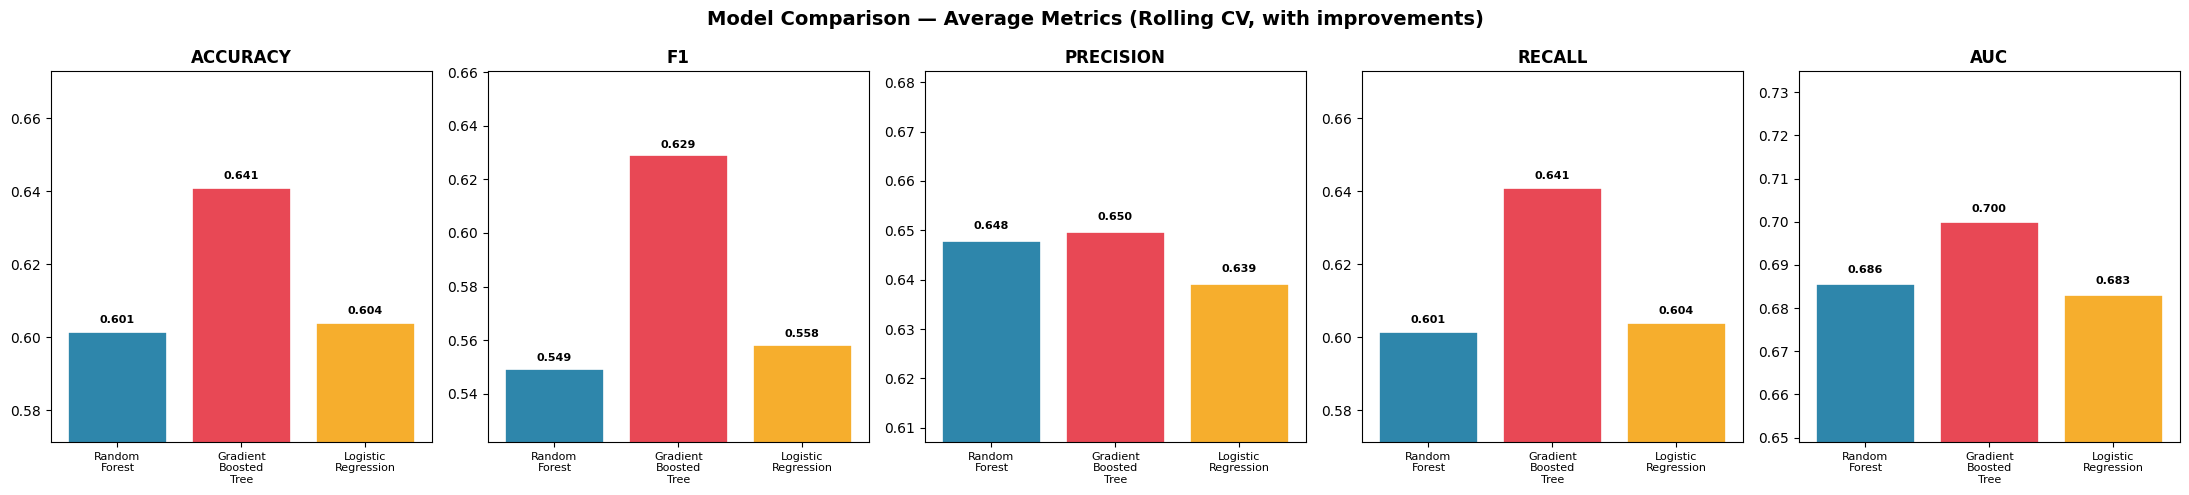

In [91]:
MODEL_LABELS = [m.replace(" ", "\n") for m in model_names]

# ── Grouped bar chart ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(metric_keys), figsize=(22, 5))
fig.suptitle("Model Comparison — Average Metrics (Rolling CV, with improvements)",
             fontsize=14, fontweight="bold")
for ax, mk in zip(axes, metric_keys):
    vals = [avg_results[m][mk] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=COLORS[:3],
                  edgecolor="white", linewidth=1.2)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(MODEL_LABELS, fontsize=8)
    ax.set_title(mk.upper(), fontweight="bold")
    ax.set_ylim(min(vals) * 0.95, max(vals) * 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout(); plt.show()

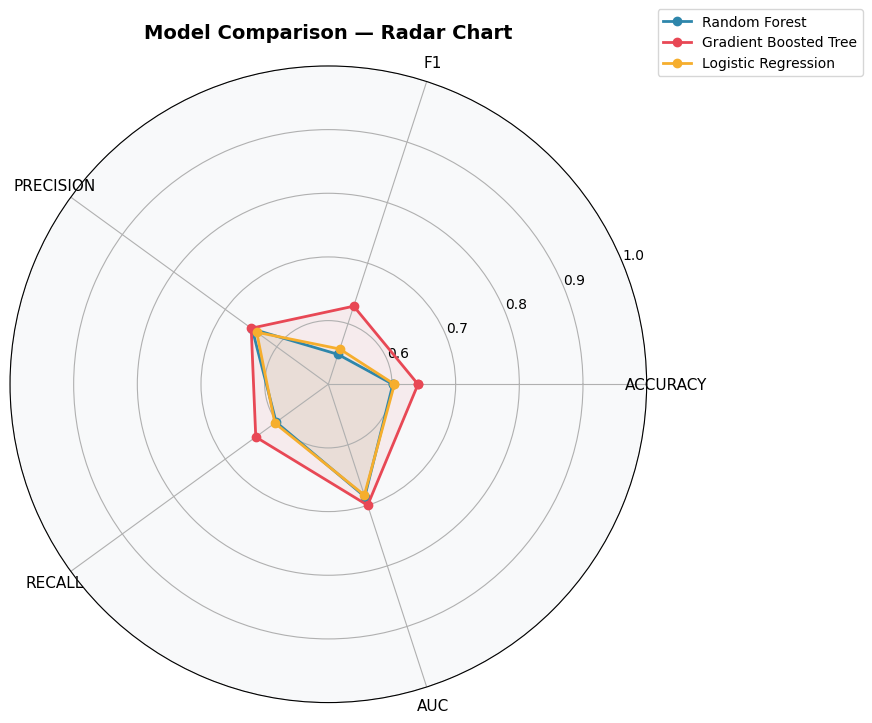

In [92]:
# ── Radar chart ────────────────────────────────────────────────────────────────
categories = [m.upper() for m in metric_keys]
N      = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor("#F8F9FA")
for idx, mname in enumerate(model_names):
    vals = [avg_results[mname][mk] for mk in metric_keys] + [avg_results[mname][metric_keys[0]]]
    ax.plot(angles, vals, "o-", linewidth=2, color=COLORS[idx], label=mname)
    ax.fill(angles, vals, alpha=0.08, color=COLORS[idx])
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison — Radar Chart", size=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout(); plt.show()

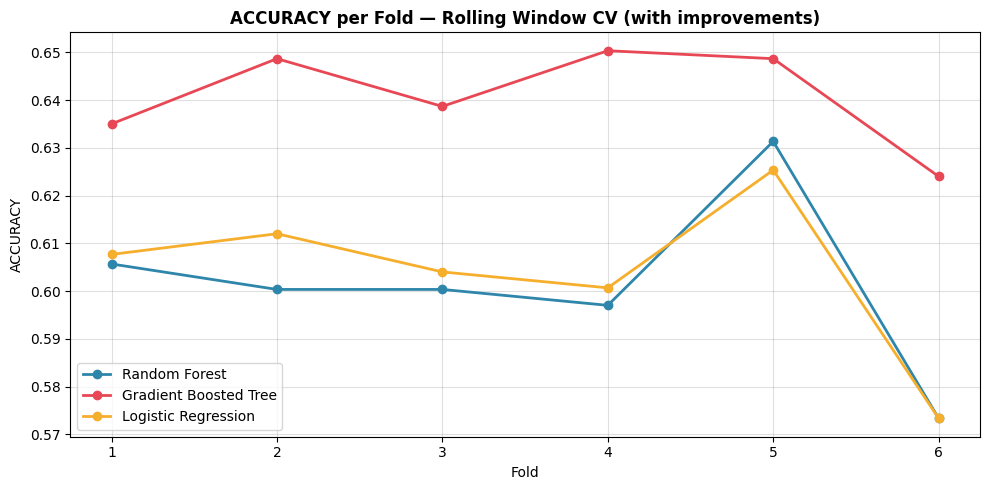

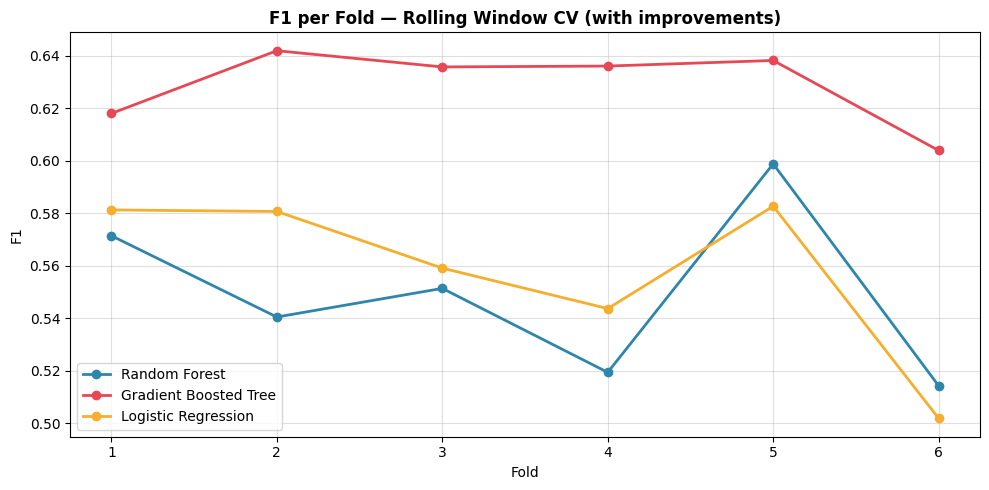

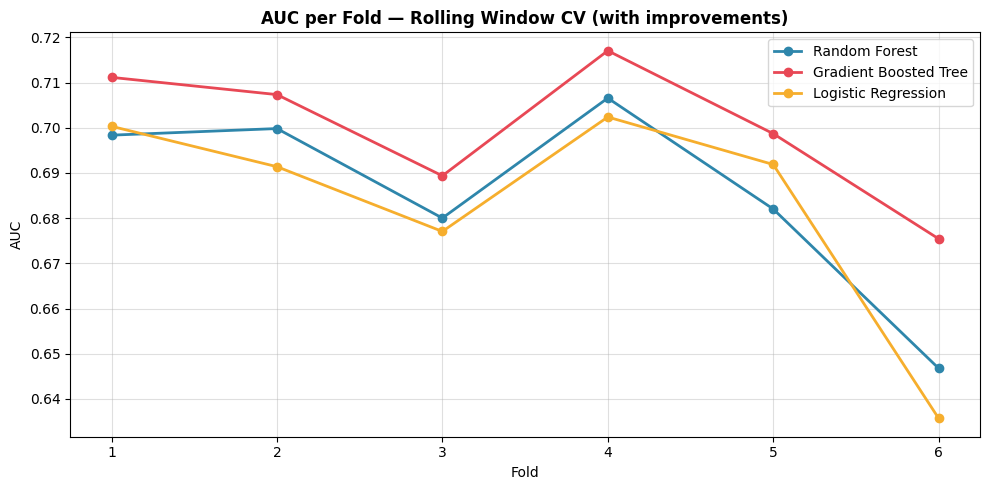

In [93]:
# ── Per-fold metric lines ──────────────────────────────────────────────────────
for mk in ["accuracy", "f1", "auc"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    for idx, mname in enumerate(model_names):
        fold_vals = [f[mk] for f in all_results[mname]]
        ax.plot(range(1, N_SPLITS + 1), fold_vals,
                marker="o", linewidth=2, color=COLORS[idx], label=mname)
    ax.set_title(f"{mk.upper()} per Fold — Rolling Window CV (with improvements)",
                 fontweight="bold")
    ax.set_xlabel("Fold"); ax.set_ylabel(mk.upper())
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.legend(); ax.grid(True, alpha=0.4)
    plt.tight_layout(); plt.show()

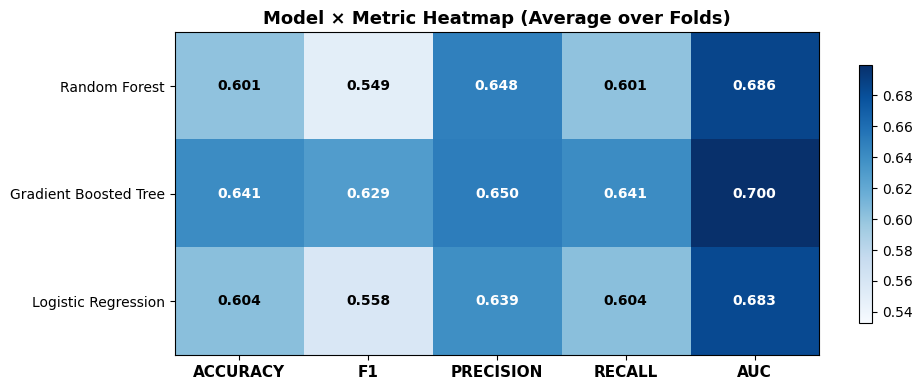

In [94]:
# ── Summary heatmap ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
heat_data = summary_df.values.astype(float)
im = ax.imshow(heat_data, cmap="Blues", aspect="auto",
               vmin=heat_data.min() * 0.97, vmax=heat_data.max())
ax.set_xticks(range(len(metric_keys)))
ax.set_xticklabels([m.upper() for m in metric_keys], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=10)
for i in range(len(model_names)):
    for j in range(len(metric_keys)):
        ax.text(j, i, f"{heat_data[i, j]:.3f}",
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white" if heat_data[i, j] > heat_data.mean() else "black")
ax.set_title("Model × Metric Heatmap (Average over Folds)", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

In [96]:
# ── Final summary ──────────────────────────────────────────────────────────────
best_by_f1  = summary_df["f1"].idxmax()
best_by_auc = summary_df["auc"].idxmax()

print(f"\n{'='*55}")
print(f"  FINAL SUMMARY")
print(f"{'='*55}")
print(f"\n{summary_df.round(4)}")
print(f"\n🏆 Best by F1  : {best_by_f1}  (F1 = {avg_results[best_by_f1]['f1']:.4f})")
print(f"🏆 Best by AUC : {best_by_auc}  (AUC = {avg_results[best_by_auc]['auc']:.4f})")
print(f"\nImprovements applied:")
# print(f"  ✔ Log-transforms on {len(skewed_cols)} skewed features")
# print(f"  ✔ {len(interaction_cols)} interaction features added")
print(f"  ✔ Expanded hyperparameter grids (featureSubsetStrategy, subsamplingRate)")
print(f"  ✔ F1-optimal decision threshold tuned per fold on eval set")

spark.stop()
print("\n✅ Project complete.")


  FINAL SUMMARY

                       accuracy      f1  precision  recall     auc
Model                                                             
Random Forest            0.6013  0.5493     0.6478  0.6013  0.6856
Gradient Boosted Tree    0.6409  0.6290     0.6497  0.6409  0.6998
Logistic Regression      0.6038  0.5582     0.6391  0.6038  0.6831

🏆 Best by F1  : Gradient Boosted Tree  (F1 = 0.6290)
🏆 Best by AUC : Gradient Boosted Tree  (AUC = 0.6998)

Improvements applied:
  ✔ Expanded hyperparameter grids (featureSubsetStrategy, subsamplingRate)
  ✔ F1-optimal decision threshold tuned per fold on eval set

✅ Project complete.


## Aggregate Results

In [ ]:
model_names = list(all_results.keys())
metric_keys = ["accuracy", "f1", "precision", "recall", "auc"]

avg_results = {
    mname: {mk: np.mean([f[mk] for f in all_results[mname]]) for mk in metric_keys}
    for mname in model_names
}

summary_df = pd.DataFrame(avg_results).T[metric_keys]
summary_df.index.name = "Model"
print("\nAverage Metrics across Rolling Folds:")
print(summary_df.round(4).to_string())


Average Metrics across Rolling Folds:
                       accuracy      f1  precision  recall     auc
Model                                                             
Random Forest            0.6349  0.6273     0.6378  0.6349  0.6860
Gradient Boosted Tree    0.6488  0.6470     0.6481  0.6488  0.7027
Logistic Regression      0.6379  0.6360     0.6375  0.6379  0.6846


## Comparison Plots

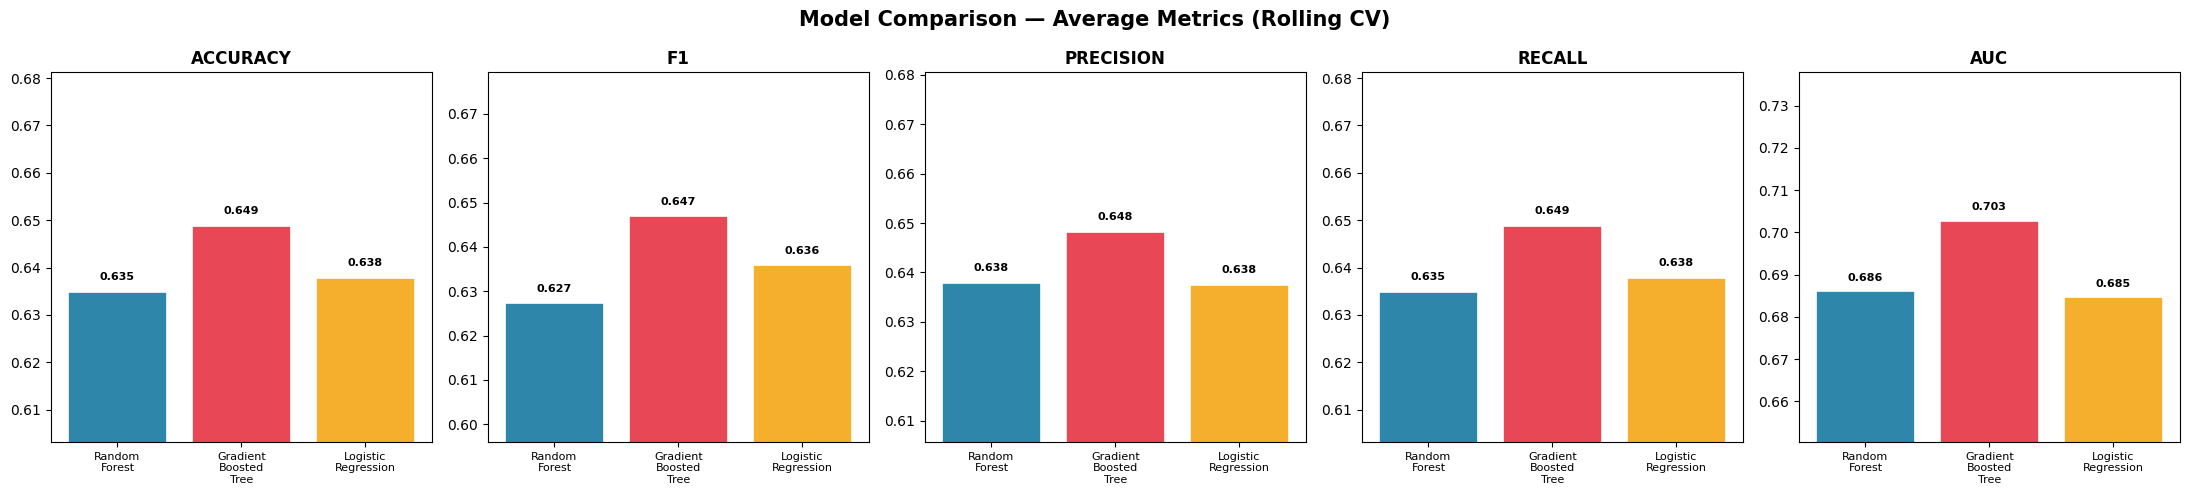

In [ ]:
COLORS       = ["#2E86AB", "#E84855", "#F6AE2D", "#2DC653"]
MODEL_LABELS = [m.replace(" ", "\n") for m in model_names]

# ── 10a. Grouped bar chart ────────────────────────────────
fig, axes = plt.subplots(1, len(metric_keys), figsize=(22, 5))
fig.suptitle("Model Comparison — Average Metrics (Rolling CV)",
             fontsize=15, fontweight="bold")
for ax, mk in zip(axes, metric_keys):
    vals = [avg_results[m][mk] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=COLORS,
                  edgecolor="white", linewidth=1.2)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(MODEL_LABELS, fontsize=8)
    ax.set_title(mk.upper(), fontweight="bold")
    ax.set_ylim(min(vals) * 0.95, max(vals) * 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

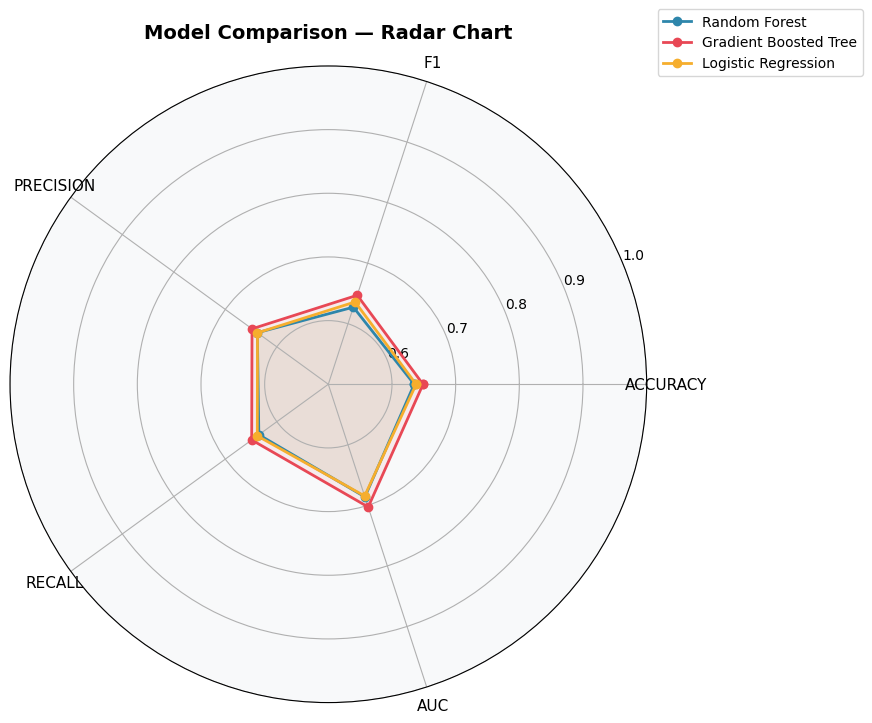

In [ ]:
# ── 10b. Radar chart ──────────────────────────────────────
categories = [m.upper() for m in metric_keys]
N      = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor("#F8F9FA")
for idx, mname in enumerate(model_names):
    vals = [avg_results[mname][mk] for mk in metric_keys]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=COLORS[idx], label=mname)
    ax.fill(angles, vals, alpha=0.08, color=COLORS[idx])
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison — Radar Chart", size=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

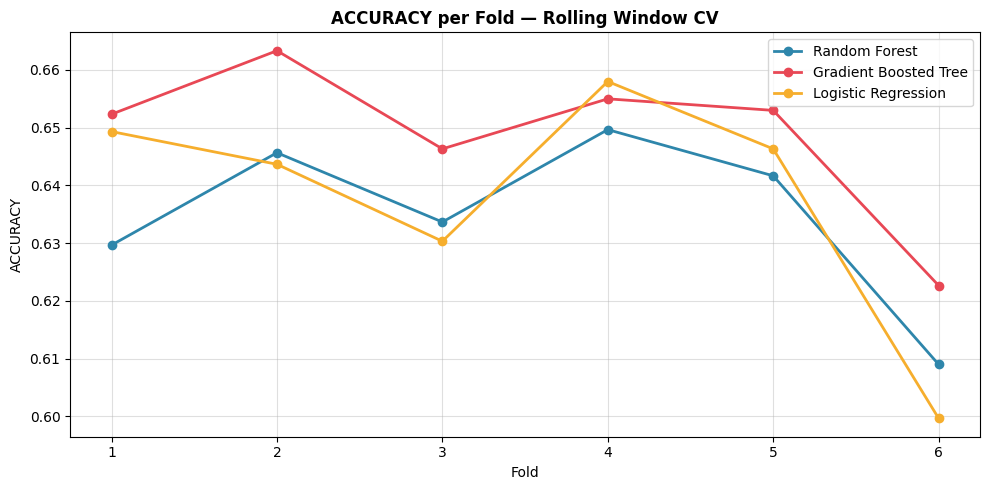

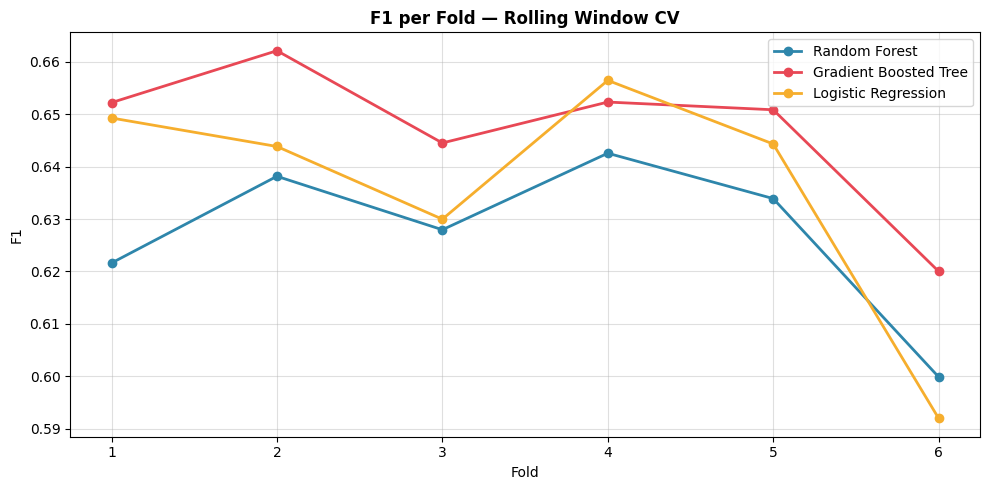

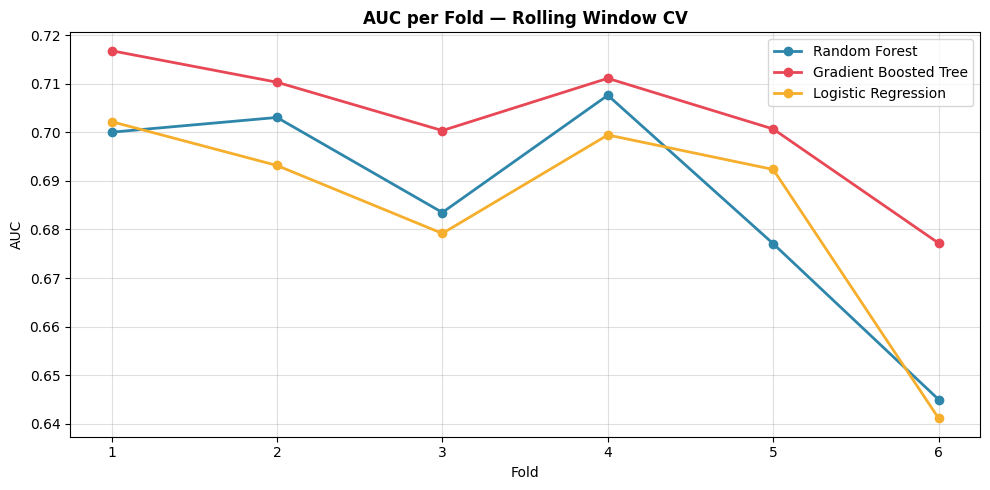

In [ ]:
for mk in ["accuracy", "f1", "auc"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    for idx, mname in enumerate(model_names):
        fold_vals = [f[mk] for f in all_results[mname]]
        ax.plot(range(1, N_SPLITS + 1), fold_vals,
                marker="o", linewidth=2, color=COLORS[idx], label=mname)
    ax.set_title(f"{mk.upper()} per Fold — Rolling Window CV", fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(mk.upper())
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

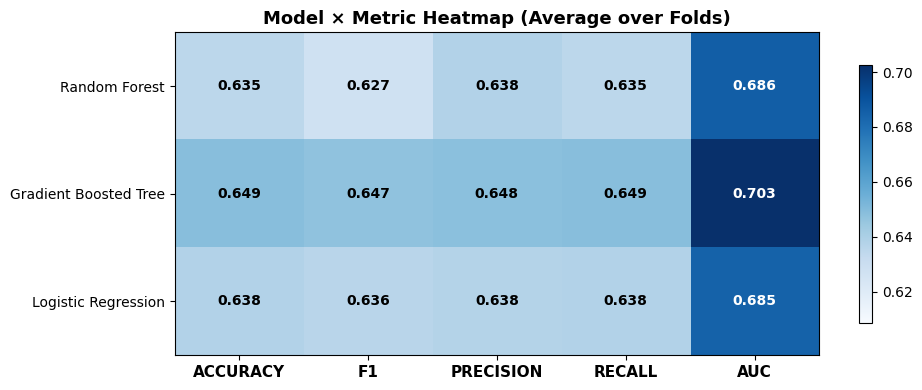

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
heat_data = summary_df.values.astype(float)
im = ax.imshow(heat_data, cmap="Blues", aspect="auto",
               vmin=heat_data.min() * 0.97, vmax=heat_data.max())
ax.set_xticks(range(len(metric_keys)))
ax.set_xticklabels([m.upper() for m in metric_keys], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=10)
for i in range(len(model_names)):
    for j in range(len(metric_keys)):
        ax.text(j, i, f"{heat_data[i, j]:.3f}",
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white" if heat_data[i, j] > heat_data.mean() else "black")
ax.set_title("Model × Metric Heatmap (Average over Folds)",
             fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
best_by_f1  = summary_df["f1"].idxmax()
best_by_auc = summary_df["auc"].idxmax()

print(f"\n📊 Summary Table:\n{summary_df.round(4)}")
print(f"\n🏆 Best by F1  : {best_by_f1}   "
      f"(F1={avg_results[best_by_f1]['f1']:.4f})")
print(f"🏆 Best by AUC : {best_by_auc}  "
      f"(AUC={avg_results[best_by_auc]['auc']:.4f})")
print("\nAll plots saved to /mnt/user-data/outputs/")

spark.stop()
print("\n✅ Project complete.")


📊 Summary Table:
                       accuracy      f1  precision  recall     auc
Model                                                             
Random Forest            0.6349  0.6273     0.6378  0.6349  0.6860
Gradient Boosted Tree    0.6488  0.6470     0.6481  0.6488  0.7027
Logistic Regression      0.6379  0.6360     0.6375  0.6379  0.6846

🏆 Best by F1  : Gradient Boosted Tree   (F1=0.6470)
🏆 Best by AUC : Gradient Boosted Tree  (AUC=0.7027)

All plots saved to /mnt/user-data/outputs/

✅ Project complete.
